# aggregate_rna_metacell.R

In [2]:
here::i_am("rna/metacells/run/aggregate_rna_metacell.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

library(reticulate)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [3]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"

In [4]:
## START TEST ##
args = list()
args$metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$sce <- file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
# args$cell2metacell <- file.path(io$basedir,sprintf("results/rna/metacells/%s/cell2metacell_assignment.txt.gz",opts$samples))
# args$cell2metacell <- file.path(io$basedir,"results/rna/metacells/trajectories/nmp/cell2metacell_assignment.txt.gz")
args$cell2metacell <- file.path(io$basedir,"results/rna/metacells/trajectories/nmp/cell2metacell_assignment.txt.gz")
args$python <- "/rds/project/rds-SDzz0CATGms/users/bt392/miniconda3/envs/env_multiome/bin/python" # "/Users/argelagr/opt/anaconda3/envs/main/bin/python"
args$metacell_min_reads <- 2e4
args$normalisation_method <- "cpm"
args$outdir <- file.path(io$basedir,"results/rna_atac/gene_regulatory_networks/metacells/trajectories/from_scratch")
## END TEST ##

In [7]:
#####################
## Define settings ##
#####################

stopifnot(file.exists(args$cell2metacell))
dir.create(args$outdir, showWarnings = F, recursive = TRUE)

# Reticulate
use_python(args$python, required = TRUE)
sc <- import("scanpy")

In [10]:
###########################
## Load metacell results ##
###########################

cell2metacell.dt <- args$cell2metacell %>% map(~ fread(.)) %>% rbindlist
# stopifnot(mapping_mnn.dt$cell%in%sample_metadata$cell)

print(sprintf("Number of metacells: %s", length(unique(cell2metacell.dt$metacell))))


[1] "Number of metacells: 385"


In [11]:
###################
## Load metadata ##
###################

sample_metadata <- fread(args$metadata) %>%
  # .[cell%in%cell2metacell.dt$cell] %>%
  # .[,c("cell","sample","stage","genotype","celltype.mapped","closest.cell")] %>%
  # setnames("celltype.mapped","celltype") %>%
  merge(cell2metacell.dt,"cell")

In [14]:
###############################
## Load SingleCellExperiment ##
###############################

sce <- load_SingleCellExperiment(file=args$sce, cells=sample_metadata$cell)
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

table(sce$metacell)


       E8.0_rep1#AAAGCGGGTGCTTTAC-1        E8.0_rep1#AAGCGAGGTTACTAGG-1 
                                 17                                  11 
       E8.0_rep1#AAGTTAGCAGCATGTC-1        E8.0_rep1#AATAACCGTACGGTAC-1 
                                 19                                  15 
       E8.0_rep1#AATGTCATCGTTTCTG-1        E8.0_rep1#AATTAGCGTTAGTTGG-1 
                                 19                                  17 
       E8.0_rep1#ACCACACCAGCATTAT-1        E8.0_rep1#AGAACCAAGCCTGATG-1 
                                 13                                  22 
       E8.0_rep1#AGAACCGCATTGCGAC-1        E8.0_rep1#AGCATCCCATTTAAGC-1 
                                 11                                  20 
       E8.0_rep1#AGGATGTCAAATATCC-1        E8.0_rep1#AGTCAATGTAGCCTCC-1 
                                 20                                  18 
       E8.0_rep1#AGTTGCGTCACAGCGC-1        E8.0_rep1#ATGCATTCACTTACAG-1 
                                  8               

In [17]:
######################
## Filter metacells ##
######################

# nreads_per_metacell.dt <- data.table(
#   metacell = colnames(sce_pseudobulk),
#   nreads = colSums(counts(sce_pseudobulk))
# )
nreads_per_metacell.dt <- sample_metadata[,.(nreads=sum(nFeature_RNA)),by="metacell"]

# Plot
p <- gghistogram(nreads_per_metacell.dt[nreads<=1e6], x="nreads", y="..density..", bins=100, fill="gray70", color="gray50") +
  geom_vline(xintercept=args$metacell_min_reads, linetype="dashed") +
  labs(x="Number of reads per metacell", y="Density") +
  theme(
    axis.text =  element_text(size=rel(0.8)),
    axis.title.x = element_blank()
  )

pdf(file.path(args$outdir,"nreads_metacell_threshold.pdf"), width=8, height=4)
print(p)
dev.off()

png 
  2

In [18]:
# Filter
print(sprintf("Removing metacells that have less than %d reads (%d/%d)", args$metacell_min_reads, nreads_per_metacell.dt[nreads<=args$metacell_min_reads,.N], nrow(nreads_per_metacell.dt)))

metacells.to.use <- intersect(sample_metadata$cell, nreads_per_metacell.dt[nreads>=args$metacell_min_reads,metacell])
sample_metadata <- sample_metadata[metacell%in%metacells.to.use]
cell2metacell.dt <- cell2metacell.dt[metacell%in%metacells.to.use]
sce <- sce[,colnames(sce)%in%sample_metadata$cell]

###################################
## Aggregate counts per metacell ##
###################################

sce_pseudobulk <- pseudobulk_sce_fn(
  x = sce,
  assay = "counts",
  by = "metacell",
  fun = "sum",
  scale = FALSE # Should pseudo-bulks be scaled with the effective library size & multiplied by 1M?
)

# set assay name
assayNames(sce_pseudobulk) <- "counts"

[1] "Removing metacells that have less than 20000 reads (8/385)"


In [20]:
###################
## Normalisation ##
###################

if (args$normalisation_method=="deseq2") {
  
  suppressPackageStartupMessages(library(DESeq2))
  dds <- DESeqDataSet(sce_pseudobulk, design=~1)
  dds <- varianceStabilizingTransformation(dds)
  logcounts(sce_pseudobulk) <- assay(dds)
  
} else if (args$normalisation_method=="cpm") {
  
  logcounts(sce_pseudobulk) <- log2(1e6*(sweep(counts(sce_pseudobulk),2,colSums(counts(sce_pseudobulk)),"/"))+1)
  # atac.mtx <- log2(t(t(assay(atac.se)) / colSums(assay(atac.se))) * 1e6)
  
} else {
  stop("Normalisation method not recognised")
}

In [21]:
##############################
## Define metacell metadata ##
##############################

metacell_metadata.dt <- sample_metadata %>%
  .[,c("cell","sample","stage","genotype","celltype","closest.cell")] %>%
  .[cell%in%colnames(sce_pseudobulk)] %>% setkey(cell) %>% .[colnames(sce_pseudobulk)] %>%
  setnames("cell","metacell") %>%
  merge(cell2metacell.dt[,.(ncells=.N),by="metacell"],by="metacell")

# Add QC stats
tmp <- data.table(
  metacell = colnames(sce_pseudobulk), 
  nFeature_RNA = colSums(counts(sce_pseudobulk))
)
metacell_metadata.dt <- metacell_metadata.dt %>% merge(tmp,by="metacell")

# Add metacell metadata as colData
stopifnot(metacell_metadata.dt$metacell == colnames(sce_pseudobulk))
colData(sce_pseudobulk) <- metacell_metadata.dt %>% tibble::column_to_rownames("metacell") %>% DataFrame

In [22]:
#############################################
## Convert SingleCellExperiment to anndata ##
#############################################

adata_sce <- sc$AnnData(
    X   = t(counts(sce_pseudobulk)),
    obs = as.data.frame(colData(sce_pseudobulk)),
    var = data.frame(gene=rownames(sce_pseudobulk), row.names=rownames(sce_pseudobulk))
)


# Add cell type colors
# adata_sce$uns$update(celltype_colors = opts$celltype.colors[sort(unique(as.character(adata_sce$obs$celltype)))])
# adata_sce$uns["celltype_colors"]

##########
## Save ##
##########

adata_sce$write_h5ad(file.path(args$outdir,"anndata_metacells.h5ad"))
fwrite(metacell_metadata.dt, file.path(args$outdir,"metacells_metadata.txt.gz"), sep="\t", quote=F, na="NA")
saveRDS(sce_pseudobulk, file.path(args$outdir,"SingleCellExperiment_metacells.rds"))

In [29]:
sce_pseudobulk

class: SingleCellExperiment 
dim: 32285 377 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(377): E8.0_rep1#AAAGCGGGTGCTTTAC-1
  E8.0_rep1#AAGCGAGGTTACTAGG-1 ... E8.75_rep2#TTTAACGAGCCTGATG-1
  E8.75_rep2#TTTCCTGAGGTCTTGG-1
colData names(7): sample stage ... ncells nFeature_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

# aggregate_atac_metacell

In [35]:
suppressPackageStartupMessages(library(ArchR))
addArchRVerbose(verbose = FALSE)

Setting addArchRVerbose = FALSE



In [5]:
###################
## Load settings ##
###################

# START TEST ##
args$archr_directory <- file.path(io$basedir,"data/processed/atac/archR")
args$metadata <- file.path(io$basedir,"results/atac/archR/celltype_assignment/sample_metadata_after_celltype_assignment.txt.gz")
args$cell2metacell <- file.path(io$basedir,"results/rna/metacells/trajectories/nmp/cell2metacell_assignment.txt.gz")
args$matrices <- c("PeakMatrix") # c("PeakMatrix", "GeneScoreMatrix_distal", "GeneScoreMatrix_TSS")
args$metacell_min_frags <- 2e5
## END TEST ##

In [25]:
###########################
## Load metacell results ##
###########################

cell2metacell.dt <- args$cell2metacell %>% map(~ fread(.)) %>% rbindlist

###################
## Load metadata ##
###################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE] %>% # temporary 
  # .[cell%in%cell2metacell.dt$cell] %>%
  # .[,c("cell","sample","stage","genotype","celltype.mapped","closest.cell")] %>%
  merge(cell2metacell.dt,"cell")

print(sprintf("Number of metacells before filtering by minimum number of fragments: %s", length(unique(sample_metadata$metacell))))

[1] "Number of metacells before filtering by minimum number of fragments: 385"


In [26]:
######################
## Filter metacells ##
######################

nfrags_per_metacell.dt <- sample_metadata[,.(nfrags=sum(nFrags_atac)),by="metacell"]

# Plot
p <- gghistogram(nfrags_per_metacell.dt[nfrags<=5e6], x="nfrags", y="..density..", bins=100, fill="gray70", color="gray50") +
  geom_vline(xintercept=args$metacell_min_frags, linetype="dashed") +
  labs(x="Number of ATAC fragments per metacell", y="Density") +
  theme(
    axis.text =  element_text(size=rel(0.8)),
    axis.title.x = element_blank()
  )

pdf(file.path(args$outdir,"nfrags_metacell_threshold.pdf"), width=8, height=4)
print(p)
dev.off()

metacells.to.use <- intersect(sample_metadata$cell, nfrags_per_metacell.dt[nfrags>=args$metacell_min_frags,metacell])
sample_metadata <- sample_metadata[metacell%in%metacells.to.use]
cell2metacell.dt <- cell2metacell.dt[metacell%in%metacells.to.use]

print(sprintf("Number of metacells after filtering by total number of fragments: %s", length(unique(sample_metadata$metacell))))

png 
  2

[1] "Number of metacells after filtering by total number of fragments: 332"


In [27]:
########################
## Load ArchR Project ##
########################

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = 1) 

ArchRProject <- loadArchRProject(args$archr_directory)

# Subset metacells
ArchRProject <- ArchRProject[sample_metadata$cell]

# Sanity checks
stopifnot(args$matrices%in%getAvailableMatrices(ArchRProject))

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [32]:
#############################################
## Add metacell assignment to ArchR object ##
#############################################

tmp <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject)] %>% setkey(cell) %>% .[rownames(ArchRProject)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")
stopifnot(all(rownames(tmp) == rownames(getCellColData(ArchRProject))))
ArchRProject <- addCellColData(
  ArchRProject,
  data = tmp$metacell,
  name = "metacell",
  cells = rownames(tmp),
  force = TRUE
)

In [36]:
###################################################
## Pseudobulk into a SummarizedExperiment object ##
###################################################

# i <- "PeakMatrix"
for (i in args$matrices) {
  print(sprintf("Calculating pseudobulk matrix for %s",i))
  
  # summarise
  atac_metacells.se <- getGroupSE(ArchRProject, groupBy = "metacell", useMatrix = i, divideN = FALSE)
  
  # rename features
  if (grepl("peak",tolower(i),ignore.case=T)) {
    rownames(atac_metacells.se) <- rowData(atac_metacells.se) %>% as.data.table %>% .[,idx:=sprintf("%s:%s-%s",seqnames,start,end)] %>% .$id
  }
  if (grepl("gene",tolower(i),ignore.case=T)) {
    rownames(atac_metacells.se) <- rowData(atac_metacells.se)$name
  }
  
  # TO-DO: ADD CELL METADATA LIKE CELLTYPE
  # colData(atac_metacells.se) <- metacell_metadata.dt %>% tibble::column_to_rownames("metacell") %>% DataFrame
  
  # save
  saveRDS(atac_metacells.se, file.path(args$outdir,sprintf("%s_summarized_experiment_metacells.rds",i)))
}

[1] "Calculating pseudobulk matrix for PeakMatrix"


In [37]:
##############################
## Define metacell metadata ##
##############################

metacell_metadata.dt <- sample_metadata %>%
  .[cell%in%colnames(atac_metacells.se)] %>% setkey(cell) %>% .[colnames(atac_metacells.se)] %>%
  .[,c("metacell", "cell", "sample", "stage", "genotype",  "celltype", "closest.cell")] %>%
  merge(cell2metacell.dt[,.(ncells=.N),by="metacell"],by="metacell")

# Add QC stats
tmp <- data.table(
  metacell = colnames(atac_metacells.se), 
  nFrags_atac = colSums(assay(atac_metacells.se))
)
metacell_metadata.dt <- metacell_metadata.dt %>% merge(tmp,by="metacell")

In [38]:
####################################
## Plot coverage before and after ##
####################################

to.plot <- rbind(
  metacell_metadata.dt[,c("metacell","nFrags_atac")] %>% .[,class:="metacell"],
  sample_metadata[,c("metacell","nFrags_atac")] %>% .[,class:="cell"]
) %>% .[,log_nFrags_atac:=log10(nFrags_atac)] 

p <- gghistogram(to.plot, x="log_nFrags_atac", fill="class", bins=100) +
  labs(x="Number of ATAC fragments (log10)") +
  theme(
    legend.title = element_blank(),
    axis.text = element_text(size=rel(0.75), color="black")
  )

pdf(file.path(args$outdir,"nfrags_before_vs_after.pdf"), width=7, height=4)
print(p)
dev.off()

png 
  2

In [39]:
##########
## Save ##
##########

fwrite(metacell_metadata.dt, file.path(args$outdir,"metacells_metadata.txt.gz"), sep="\t", quote=F, na="NA")

# run_cor_TFexpr_vs_peakAcc_metacells

In [6]:
## START TEST ##
args$sce <- file.path(args$outdir,"SingleCellExperiment_metacells.rds")
args$atac_peak_matrix <- file.path(args$outdir,"PeakMatrix_summarized_experiment_metacells.rds")
args$motif_annotation <- "CISBP"
args$motifmatcher <- file.path(io$basedir,sprintf("data/processed/atac/archR/Annotations/%s-Scores.rds",args$motif_annotation))
args$motif2gene <- file.path(io$basedir,sprintf("data/processed/atac/archR/Annotations/%s_motif2gene.txt.gz",args$motif_annotation))
## END TEST ##

In [45]:
#######################
## Load RNA and ATAC ##
#######################

# Load SingleCellExperiment
rna_metacells.sce <- readRDS(args$sce)

# Load ATAC SummarizedExperiment
atac_peakMatrix_metacells.se <- readRDS(args$atac_peak_matrix)

# Normalise ATAC data
assayNames(atac_peakMatrix_metacells.se) <- "counts"
assay(atac_peakMatrix_metacells.se,"logcounts") <- log(1e6*(sweep(assay(atac_peakMatrix_metacells.se),2,colSums(assay(atac_peakMatrix_metacells.se),na.rm=T),"/"))+1)

# Make sure that samples are consistent
samples <- intersect(colnames(rna_metacells.sce),colnames(atac_peakMatrix_metacells.se))
rna_metacells.sce <- rna_metacells.sce[,samples]
atac_peakMatrix_metacells.se <- atac_peakMatrix_metacells.se[,samples]

print(sprintf("Number of metacells: %s",length(samples)))

[1] "Number of metacells: 331"


In [59]:
###############################
## Load motifmatcher results ##
###############################

motifmatcher.se <- readRDS(args$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac_peakMatrix_metacells.se)))
motifmatcher.se <- motifmatcher.se[rownames(atac_peakMatrix_metacells.se),]

###########################
## Load motif annotation ##
###########################

motif2gene.dt <- fread(args$motif2gene)

In [ ]:
################
## Filter TFs ##
################

motifs <- intersect(colnames(motifmatcher.se),motif2gene.dt$motif)
motifmatcher.se <- motifmatcher.se[,motifs]
motif2gene.dt <- motif2gene.dt[motif%in%motifs]

genes <- intersect(toupper(rownames(rna_metacells.sce)),motif2gene.dt$gene)
rna_tf_metacells.sce <- rna_metacells.sce[str_to_title(genes),]
rownames(rna_tf_metacells.sce) <- toupper(rownames(rna_tf_metacells.sce))
motif2gene.dt <- motif2gene.dt[gene%in%genes]

# Manually remove some motifs
motif2gene.dt <- motif2gene.dt[!motif%in%c("T_789")]

# Remove duplicated gene-motif pairs
genes.to.remove <- names(which(table(motif2gene.dt$gene)>1))
cat(sprintf("Removing %d TFs that have duplicated gene-motif pairs:\n%s", length(genes.to.remove), paste(genes.to.remove, collapse=", ")))
motif2gene.dt <- motif2gene.dt[!gene%in%genes.to.remove]
rna_tf_metacells.sce <- rna_tf_metacells.sce[rownames(rna_tf_metacells.sce)%in%motif2gene.dt$gene]
motifmatcher.se <- motifmatcher.se[,colnames(motifmatcher.se)%in%motif2gene.dt$motif]
stopifnot(table(motif2gene.dt$gene)==1)

Removing 0 TFs that have duplicated gene-motif pairs:


In [64]:
#########################################################
## Correlate peak accessibility with TF RNA expression ##
#########################################################

# Sanity checks
stopifnot(colnames(rna_tf_metacells.sce)==colnames(atac_peakMatrix_metacells.se))

TFs <- rownames(rna_tf_metacells.sce)

# Prepare output data objects
cor.mtx <- matrix(as.numeric(NA), nrow=nrow(atac_peakMatrix_metacells.se), ncol=length(TFs))
pvalue.mtx <- matrix(as.numeric(NA), nrow=nrow(atac_peakMatrix_metacells.se), ncol=length(TFs))
rownames(cor.mtx) <- rownames(atac_peakMatrix_metacells.se); colnames(cor.mtx) <- TFs
dimnames(pvalue.mtx) <- dimnames(cor.mtx)

# i <- "GATA1"
for (i in TFs) {
  motif_i <- motif2gene.dt[gene==i,motif]
  
  print(i)
  all_peaks_i <- rownames(motifmatcher.se)[which(assay(motifmatcher.se[,motif_i],"motifMatches")==1)]
  
  # calculate correlations
  corr_output <- psych::corr.test(
    x = t(logcounts(rna_tf_metacells.sce[i,])), 
    y = t(assay(atac_peakMatrix_metacells.se[all_peaks_i,],"logcounts")), 
    ci = FALSE
  )
  
  # Fill matrices
  cor.mtx[all_peaks_i,i] <- round(corr_output$r[1,],3)
  pvalue.mtx[all_peaks_i,i] <- round(corr_output$p[1,],10)
}

[1] "SOX17"
[1] "MYBL1"
[1] "MSC"
[1] "TFAP2D"
[1] "TFAP2B"
[1] "ARID5A"
[1] "NPAS2"
[1] "RFX8"
[1] "POU3F3"
[1] "STAT4"
[1] "STAT1"
[1] "HSFY2"


Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”


[1] "KLF7"
[1] "CREB1"
[1] "FEV"
[1] "PAX3"
[1] "GBX2"
[1] "TWIST2"
[1] "TFCP2L1"
[1] "GLI2"
[1] "EN1"
[1] "ELK4"
[1] "SOX13"
[1] "MYOG"
[1] "ELF3"
[1] "NR5A2"
[1] "LHX9"
[1] "LHX4"
[1] "PRRX1"
[1] "TBX19"
[1] "POU2F1"
[1] "RXRG"
[1] "LMX1A"
[1] "PBX1"
[1] "ATF6"
[1] "NR1I3"
[1] "USF1"
[1] "NHLH1"
[1] "MIXL1"
[1] "HLX"
[1] "ESRRG"
[1] "PROX1"
[1] "BATF3"
[1] "ATF3"
[1] "IRF6"
[1] "GATA3"
[1] "PTF1A"
[1] "TBPL2"
[1] "PAX8"
[1] "LHX3"
[1] "RXRA"
[1] "GFI1B"
[1] "BARHL1"
[1] "PRRX2"
[1] "NAIF1"
[1] "LMX1B"
[1] "PBX3"
[1] "LHX6"
[1] "ZBTB6"
[1] "LHX2"
[1] "NR5A1"
[1] "NR6A1"
[1] "NR4A2"
[1] "TBR1"
[1] "SP5"
[1] "DLX1"
[1] "DLX2"
[1] "SP3"
[1] "SP9"
[1] "ATF2"
[1] "EVX2"
[1] "HOXD13"
[1] "HOXD12"


Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”


[1] "HOXD11"
[1] "HOXD10"
[1] "HOXD9"
[1] "HOXD8"
[1] "HOXD3"
[1] "HOXD4"
[1] "HOXD1"
[1] "NFE2L2"
[1] "NEUROD1"
[1] "SPI1"
[1] "NR1H3"
[1] "CREB3L1"
[1] "ALX4"
[1] "EHF"
[1] "ELF5"
[1] "LMO2"
[1] "WT1"
[1] "PAX6"
[1] "MEIS2"
[1] "MGA"
[1] "CENPB"
[1] "INSM1"
[1] "NKX2-4"
[1] "NKX2-2"
[1] "PAX1"
[1] "FOXA2"
[1] "VSX1"
[1] "SCRT2"
[1] "TCF15"
[1] "SOX12"
[1] "ID1"
[1] "FOXS1"


...

Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”


[1] "RORB"
[1] "KLF9"
[1] "FOXD4"
[1] "DMRT1"
[1] "DMRT3"
[1] "DMRT2"
[1] "RFX3"
[1] "GLIS3"
[1] "HHEX"
[1] "LCOR"
[1] "NKX2-3"
[1] "PAX2"
[1] "TLX1"
[1] "LBX1"
[1] "PITX3"
[1] "NFKB2"
[1] "MXI1"
[1] "TCF7L2"
[1] "VAX1"
[1] "EMX2"
[1] "FOXP3"
[1] "TFE3"
[1] "GATA1"
[1] "ELK1"
[1] "ZBTB33"
[1] "ELF4"
[1] "ZIC3"
[1] "SOX3"
[1] "MECP2"
[1] "NR0B1"
[1] "ARX"
[1] "ZFX"
[1] "AR"
[1] "FOXO4"
[1] "CDX4"
[1] "TBX22"
[1] "POU3F4"
[1] "HDX"
[1] "ESX1"
[1] "KLF8"
[1] "YY2"


Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”


[1] "SRY"


Warning message in cor(x, y, use = use, method = method):
“the standard deviation is zero”


In [65]:

##########
## Save ##
##########

to.save <- SummarizedExperiment(
  assays = SimpleList("cor" = dropNA(cor.mtx), "pvalue" = dropNA(pvalue.mtx)),
  rowData = rowData(atac_peakMatrix_metacells.se)
)
saveRDS(to.save, file.path(args$outdir,sprintf("%s_cor_TFexpr_vs_peakAcc.rds",args$motif_annotation)))

# create_virtual_chipseq_library_metacells

In [7]:
args$peak_metadata <- file.path(io$basedir,"data/processed/atac/archR/PeakCalls/peak_metadata.tsv.gz")
args$tf2peak_cor <- file.path(args$outdir,sprintf("%s_cor_TFexpr_vs_peakAcc.rds",args$motif_annotation))
# args$max_acc_score <- 4.5
args$min_peak_score <- 15
args$min_number_peaks <- 50
# args$outdir <- file.path(io$basedir,"results/rna_atac/virtual_chipseq/metacells/JASPAR/test")
#args$outdir <- file.path(io$basedir,sprintf("results/rna_atac/virtual_chipseq/metacells/trajectories/nmp/%s/test",args$motif_annotation))
args$threads <- 1

#####################
## Define settings ##
#####################

# I/O
dir.create(args$outdir, showWarnings = F, recursive = T)

# Parallel processing
# plan(sequential)
#plan(multisession, workers=args$threads)

In [78]:
###############################
## Load pseudobulk ATAC data ##
###############################

# Load ATAC SummarizedExperiment
atac_peak_matrix_metacells.se <- readRDS(args$atac_peak_matrix)

# Normalise
assayNames(atac_peak_matrix_metacells.se) <- "counts"
assay(atac_peak_matrix_metacells.se,"logcounts") <- log2(1e6*(sweep(assay(atac_peak_matrix_metacells.se),2,colSums(assay(atac_peak_matrix_metacells.se)),"/"))+0.5)

# Load peak metadata
peak_metadata.dt <- fread(args$peak_metadata) %>% 
  # .[score>=args$min_peak_score] %>%
  .[,idx:=sprintf("%s:%s-%s",chr,start,end)]

In [79]:

######################
## Load motifmatchR ##
######################

motifmatcher.se <- readRDS(args$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac_peak_matrix_metacells.se)))
motifmatcher.se <- motifmatcher.se[rownames(atac_peak_matrix_metacells.se),]

In [80]:
###############################
## Load TF2peak correlations ##
###############################

tf2peak_cor.se <- readRDS(args$tf2peak_cor)

stopifnot(rownames(tf2peak_cor.se)%in%rownames(motifmatcher.se))
stopifnot(rownames(tf2peak_cor.se)%in%rownames(atac_peak_matrix_metacells.se))

In [81]:
##################
## Subset peaks ##
##################

peaks <- Reduce(intersect,list(rownames(motifmatcher.se),rownames(tf2peak_cor.se),peak_metadata.dt$idx))

print(sprintf("Number of peaks: %s",length(peaks)))

# motifmatcher.se <- motifmatcher.se[peaks,]
tf2peak_cor.se <- tf2peak_cor.se[peaks,]
atac_peak_matrix_metacells.se <- atac_peak_matrix_metacells.se[peaks,]
peak_metadata.dt <- peak_metadata.dt[idx%in%peaks]

[1] "Number of peaks: 192251"


In [82]:
################################
## Load motif2gene annotation ##
################################

motif2gene.dt <- fread(args$motif2gene)

# Manually remove some motifs
motif2gene.dt <- motif2gene.dt[!motif%in%c("T_789")]

In [83]:
################
## Rename TFs ##
################

motifs <- intersect(colnames(motifmatcher.se),motif2gene.dt$motif)
TFs <- intersect(colnames(tf2peak_cor.se),motif2gene.dt$gene)

motif2gene_filt.dt <- motif2gene.dt[motif%in%motifs & gene%in%TFs]
motifs <- motif2gene_filt.dt$motif
TFs <- motif2gene_filt.dt$gene

tmp <- TFs; names(tmp) <- motifs

stopifnot(motif2gene_filt.dt$motif%in%colnames(motifmatcher.se))
stopifnot(motif2gene_filt.dt$gene%in%colnames(tf2peak_cor.se))

motifmatcher.se <- motifmatcher.se[,motifs]
colnames(motifmatcher.se) <- tmp[colnames(motifmatcher.se)]
tf2peak_cor.se <- tf2peak_cor.se[,TFs]
stopifnot(colnames(motifmatcher.se)==colnames(tf2peak_cor.se))

In [84]:
##################
## Prepare data ##
##################

tf2peak_cor.mtx <- assay(tf2peak_cor.se,"cor")
motifmatcher.mtx <- assay(motifmatcher.se,"motifScores")
atac.mtx <- assay(atac_peak_matrix_metacells.se[peaks,],"logcounts") %>% round(3)

In [87]:
######################################
## Create virtual chip-seq library ##
######################################

print("Predicting TF binding sites...")

# opts$TFs <- c("T", "ZIC2", "SOX2", "TAL1", "GATA1", "FOXA2", "GATA4", "NKX2-5")
opts$TFs <- TFs
stopifnot(!duplicated(opts$TFs))
print(sprintf("Number of TFs: %s",length(opts$TFs)))

# i <- "GATA1"
# virtual_chip.dt <- opts$TFs %>% future_map(function(i) {
virtual_chip.dt <- opts$TFs %>% map(function(i) {
  print(sprintf("%s (%s/%s)",i,match(i,opts$TFs),length(opts$TFs)))
  
  # motif <- motif2gene.dt[gene==i,motif]
  # stopifnot(length(motif)==1)

  # peaks <- names(which(abs(assay(tf2peak_cor.se[peaks,i],"cor")[,1])>=0))
  peaks <- names(which(abs(tf2peak_cor.mtx[,i])>0)) # we only consider chromatin activators
  
  if (length(peaks)>=args$min_number_peaks) {
    
    # calculate accessibility score
    # max_accessibility_score <- apply(assay(atac_peak_matrix_metacells.se[peaks,]),1,max) %>% round(2)
    max_accessibility_score <- apply(atac.mtx[peaks,],1,max) %>% round(2)
    # max_accessibility_score[max_accessibility_score>=args$max_acc_score] <- args$max_acc_score
    
    # calculate correlation score
    # correlation_score <- assay(tf2peak_cor.se[,i],"cor")[peaks,1] %>% round(2)
    correlation_score <- tf2peak_cor.mtx[peaks,i] %>% round(2)
    correlation_score[correlation_score==0] <- NA
    
    # calculate motif score
    # motif_score <- assay(motifmatcher.se[peaks,motif2gene.dt[gene==i,motif]],"motifScores")[,1]
    motif_score <- motifmatcher.mtx[peaks,i]
    motif_score <- round(motif_score/max(motif_score),2)
    
    # calculate motif counts
    # motif_counts <- assay(motifmatcher.se[peaks,i],"motifCounts")[,1] %>% round(2)
    
    # predicted_score <- minmax.normalisation(max_accessibility_score * correlation_score * motif_score * motif_counts) 
    predicted_score <- correlation_score * minmax.normalisation(max_accessibility_score * motif_score)
    # predicted_score <- predicted_score/max(predicted_score,na.rm=T) %>% round(2)
    
    tmp <- data.table(
      peak = peaks, 
      correlation_score = correlation_score,
      max_accessibility_score = max_accessibility_score,
      motif_score = motif_score,
      # motif_counts = motif_counts,
      score = round(predicted_score,2)
    ) %>% sort.abs("score") %>% 
      # .[motif_score==0,motif_score:=NA] %>%
      .[,c("peak","score","correlation_score","max_accessibility_score","motif_score")]
    
    # bed.dt <- tmp %>% copy %>%
    #   .[,peak:=str_replace(peak,":","-")] %>%
    #   .[,chr:=strsplit(peak,"-") %>% map_chr(1)] %>%
    #   .[,start:=strsplit(peak,"-") %>% map_chr(2)] %>%
    #   .[,end:=strsplit(peak,"-") %>% map_chr(3)] %>%
    #   .[,c("chr","start","end","score")]
    
    # Save 
#    fwrite(tmp, sprintf("%s/%s.txt.gz",args$outdir,i), sep="\t", quote=F, col.names = T)
#    fwrite(bed.dt, sprintf("%s/%s.bed.gz",args$outdir,i), sep="\t", quote=F, col.names = F)
    
    to_return.dt <- tmp[!is.na(score),c("peak","score")] %>% .[,tf:=i]
    return(to_return.dt)
  }
}) %>% rbindlist


[1] "Predicting TF binding sites..."
[1] "Number of TFs: 738"
[1] "TFAP2B (1/738)"
[1] "TFAP2D (2/738)"
[1] "TFAP2C (3/738)"
[1] "TFAP2E (4/738)"
[1] "TFAP2A (5/738)"
[1] "ARID3A (6/738)"
[1] "ARID5B (7/738)"
[1] "ARID3B (8/738)"
[1] "ARID5A (9/738)"
[1] "ARID3C (10/738)"
[1] "ARID2 (11/738)"
[1] "HMGA1 (12/738)"
[1] "HMGA2 (13/738)"
[1] "MAX (14/738)"
[1] "MLXIPL (15/738)"
[1] "ARNTL2 (16/738)"
[1] "AHRR (17/738)"
[1] "TFE3 (18/738)"
[1] "HES2 (19/738)"
[1] "MNT (20/738)"
[1] "TCF3 (21/738)"
[1] "SREBF1 (22/738)"
[1] "TFAP4 (23/738)"
[1] "HIF1A (24/738)"
[1] "TCFL5 (25/738)"
[1] "USF2 (26/738)"
[1] "TFEC (27/738)"
[1] "AHR (28/738)"
[1] "MLX (29/738)"
[1] "MYF6 (30/738)"
[1] "SIM1 (31/738)"
[1] "TFEB (32/738)"
[1] "HAND1 (33/738)"
[1] "HES1 (34/738)"
[1] "ID2 (35/738)"
[1] "EPAS1 (36/738)"
[1] "MYCL (37/738)"
[1] "ID3 (38/738)"
[1] "TCF21 (39/738)"
[1] "MXI1 (40/738)"
[1] "MYOG (41/738)"
[1] "TWIST1 (42/738)"
[1] "NEUROG3 (43/738)"
[1] "BHLHE41 (44/738)"
[1] "BHLHE23 (45/738)"
[1] "TC

In [88]:
########################
## Save sparse matrix ##
########################

virtual_chip.mtx <- virtual_chip.dt %>% 
  .[,peak:=factor(peak,levels=rownames(motifmatcher.se))] %>%
  data.table::dcast(peak~tf, value.var="score", fill=0, drop=F) %>%
  matrix.please %>% Matrix::Matrix(.)

saveRDS(virtual_chip.mtx, file.path(args$outdir,"virtual_chip_matrix.rds"))

In [92]:
###################################################################
## Update motifmatchr results using the virtual ChIP-seq library ##
###################################################################

print("Updating motifmatchr results using the virtual ChIP-seq library...")

motifmatcher_chip.se <- motifmatcher.se[,colnames(virtual_chip.mtx)]
# assays(motifmatcher_chip.se) <- assays(motifmatcher_chip.se)[c("motifScores")]

# reset motif matches
stopifnot(rownames(virtual_chip.mtx)==rownames(motifmatcher_chip.se))
stopifnot(colnames(virtual_chip.mtx)==colnames(motifmatcher_chip.se))
assay(motifmatcher_chip.se,"VirtualChipScores") <- virtual_chip.mtx
saveRDS(motifmatcher_chip.se, file.path(args$outdir,"motifmatchr_virtual_chip.rds"))

[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


# link_TF2genes_virtual_chip

In [8]:
# START TEST
args$motif_annotation <- "CISBP"
args$virtual_chip_matrix <- file.path(args$outdir,"virtual_chip_matrix.rds")
args$peak2gene <- file.path(io$basedir,"results/atac/archR/peak_calling/peaks2genes/peaks2genes_all.txt.gz")
args$distance <- 5e4
args$min_chip_score <- 0.15
args$outfile <- file.path(args$outdir, "TF2gene_after_virtual_chip.txt.gz")
# END TEST

In [96]:
###########################
## Load virtual ChIP-seq ##
###########################

virtual_chip.mtx <- readRDS(args$virtual_chip_matrix)

In [97]:
#########################################################
## Load peak2gene linkages using only genomic distance ##
#########################################################

peak2gene.dt <- fread(args$peak2gene) %>%
  # peak2gene.dt <- fread(io$archR.peak2gene.nearest) %>%
  .[dist<=args$distance] %>%
  .[,peak:=sprintf("chr%s:%s-%s",chr,peak.start,peak.end)]

# Sanity checks
stopifnot(length(intersect(rownames(virtual_chip.mtx),unique(peak2gene.dt$peak)))>1e5)

In [98]:
#########################################################
## Link TFs to target genes using the virtual ChIP-seq ##
#########################################################

tf2gene_chip.dt <- colnames(virtual_chip.mtx) %>% map(function(i) {
  print(i)
  # Select target peaks (note that we only take positive correlations into account)
  target_peaks_i <- names(which(virtual_chip.mtx[,i]>=args$min_chip_score))
  
  if (length(target_peaks_i)>=1) {
    
    tmp <- data.table(
      tf = i,
      peak = target_peaks_i,
      chip_score = virtual_chip.mtx[target_peaks_i,i]
    ) %>% merge(peak2gene.dt[peak%in%target_peaks_i,c("peak","gene","dist")], by="peak")
    
    # print(sprintf("%s: %s target peaks & %s target genes",i,length(target_peaks_i),length(unique(tmp$gene))))
    return(tmp)
  }
}) %>% rbindlist

# Save
fwrite(tf2gene_chip.dt, args$outfile, sep="\t")

[1] "AHR"
[1] "AHRR"
[1] "AIRE"
[1] "ALX1"
[1] "ALX3"
[1] "ALX4"
[1] "AR"
[1] "ARID2"
[1] "ARID3A"
[1] "ARID3B"
[1] "ARID3C"
[1] "ARID5A"
[1] "ARID5B"
[1] "ARNT"
[1] "ARNT2"
[1] "ARNTL"
[1] "ARNTL2"
[1] "ARX"
[1] "ASCL1"
[1] "ASCL2"
[1] "ATF1"
[1] "ATF2"
[1] "ATF3"
[1] "ATF4"
[1] "ATF5"
[1] "ATF6"
[1] "ATF6B"
[1] "ATF7"
[1] "ATOH1"
[1] "ATOH7"
[1] "ATOH8"
[1] "BACH1"
[1] "BACH2"
[1] "BARHL1"
[1] "BARHL2"
[1] "BARX1"
[1] "BARX2"
[1] "BATF"
[1] "BATF3"
[1] "BBX"
[1] "BCL11A"
[1] "BCL11B"
[1] "BCL6"
[1] "BCL6B"
[1] "BHLHA15"
[1] "BHLHE22"
[1] "BHLHE23"
[1] "BHLHE40"
[1] "BHLHE41"
[1] "BPTF"
[1] "BRCA1"
[1] "BSX"
[1] "CBFB"
[1] "CDC5L"
[1] "CDX1"
[1] "CDX2"
[1] "CDX4"
[1] "CEBPA"
[1] "CEBPB"
[1] "CEBPD"
[1] "CEBPG"
[1] "CEBPZ"
[1] "CENPB"
[1] "CIC"
[1] "CLOCK"
[1] "CPEB1"
[1] "CREB1"
[1] "CREB3"
[1] "CREB3L1"
[1] "CREB3L2"
[1] "CREB3L3"
[1] "CREB3L4"
[1] "CREB5"
[1] "CREM"
[1] "CRX"
[1] "CTCF"
[1] "CTCFL"
[1] "CUX1"
[1] "CUX2"
[1] "CXXC1"
[1] "DBP"
[1] "DBX2"
[1] "DDIT3"
[1] "DLX1"
[1] "DL

# build_global_GRN_metacells

In [9]:
library(cowplot)


Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend




In [10]:
#####################
## Define settings ##
#####################

# I/O
io$trajectory <- file.path("results/rna/trajectories/nmp/nmp_trajectory.txt.gz")
io$sce <- file.path(args$outdir, 'SingleCellExperiment_metacells.rds')
io$tf2gene_virtual_chip <- file.path(args$outdir, "TF2gene_after_virtual_chip.txt.gz")

# Options
# opts$celltypes <- setdiff(opts$celltypes, c("ExE_endoderm","ExE_ectoderm","Parietal_endoderm"))
opts$trajectory_name <- "nmp"
opts$min_chip_score <- 0.15
opts$max_distance <- 5e4
opts$ncores <- 4


In [104]:
####################################################
## Load TF2gene links based on in silico ChIP-seq ##
####################################################

tf2gene_chip.dt <- fread(io$tf2gene_virtual_chip) %>%
  .[chip_score>=opts$min_chip_score & dist<=opts$max_distance] %>% 
  .[,c("tf","gene")] %>% unique # Only keep TF-gene links

In [ ]:
head(fread(io$tf2gene_virtual_chip))

peak,tf,chip_score,gene,dist
<chr>,<chr>,<dbl>,<chr>,<int>
chr12:12680639-12681239,AHR,0.17,Gm27952,1575
chr12:12680639-12681239,AHR,0.17,Gm25538,19100
chr13:104497512-104498112,AHR,0.17,Adamts6,3049
chr15:40908423-40909023,AHR,0.18,Zfpm2,0
chr15:75633685-75634285,AHR,0.15,Gpihbp1,34504
chr15:75633685-75634285,AHR,0.15,Zfp41,8685


In [105]:
##############################
## Load RNA expression data ##
##############################

sce <- readRDS(io$sce)

In [106]:
##########################
## Filter TFs and genes ##
##########################

TFs <- intersect(unique(tf2gene_chip.dt$tf),toupper(rownames(sce)))
genes <- intersect(unique(tf2gene_chip.dt$gene),rownames(sce))

tf2gene_chip.dt <- tf2gene_chip.dt[tf%in%TFs & gene%in%genes,]

# Fetch RNA expression matrices
rna_tf.mtx <- logcounts(sce)[str_to_title(unique(tf2gene_chip.dt$tf)),]; rownames(rna_tf.mtx) <- toupper(rownames(rna_tf.mtx))
rna_targets.mtx <- logcounts(sce)[unique(tf2gene_chip.dt$gene),]

# Filter out lowly variable genes and TFs
rna_tf.mtx <- rna_tf.mtx[apply(rna_tf.mtx,1,var)>=1,]
rna_targets.mtx <- rna_targets.mtx[apply(rna_targets.mtx,1,var)>=0.1,]

TFs <- intersect(unique(tf2gene_chip.dt$tf),rownames(rna_tf.mtx))
genes <- intersect(unique(tf2gene_chip.dt$gene),rownames(rna_targets.mtx))
tf2gene_chip.dt <- tf2gene_chip.dt[tf%in%TFs & gene%in%genes,]

print(sprintf("Number of TFs: %s",length(TFs)))
print(sprintf("Number of genes: %s",length(genes)))

[1] "Number of TFs: 320"
[1] "Number of genes: 16209"


In [120]:
####################
## run regression ##
####################

# cvfit <- cv.glmnet(x, y, alpha=0)
# opt_ridge <- glmnet(x, y, alpha = 0, lambda  = cvfit$lambda.min)
# df <- data.frame(tf=rownames(opt_ridge$beta), gene=i, beta=as.matrix(opt_ridge$beta)[,1])

# if (opts$ncores>1){
#   plan(multicore, workers=opts$ncores)
#   genes_split <- split(genes, cut(seq_along(genes), opts$ncores, labels = FALSE)) 
# } else {
#   plan(sequential)
#   genes_split <- list(genes)
# }

# length(genes_split); sapply(genes_split,length)

# GRN_coef.dt <- genes_split %>% future_map(function(genes) {
#   tmp <- tf2gene_chip.dt[gene%in%genes]
#   genes %>% map(function(i) {
#     # print(sprintf("%s (%d/%d)",i,match(i,genes),length(genes)))
#     tfs <- tmp[gene==i,tf]
#     tfs %>% map(function(j) {
#       x <- rna_tf.mtx[j,]
#       y <- rna_targets.mtx[i,]
#       lm.fit <- lm(y~x)
#       data.frame(tf=j, gene=i, beta=round(coef(lm.fit)[[2]],3), pvalue=format(summary(lm.fit)$coefficients[2,4], digits=3))
#     }) %>% rbindlist
#   }) %>% rbindlist %>% return
# }) %>% rbindlist

# circumvent the future_map function
  tmp <- tf2gene_chip.dt
GRN_coef.dt = genes %>% map(function(i) {
    # print(sprintf("%s (%d/%d)",i,match(i,genes),length(genes)))
    tfs <- tmp[gene==i,tf]
    tfs %>% map(function(j) {
      x <- rna_tf.mtx[j,]
      y <- rna_targets.mtx[i,]
      lm.fit <- lm(y~x)
      data.frame(tf=j, gene=i, beta=round(coef(lm.fit)[[2]],3), pvalue=format(summary(lm.fit)$coefficients[2,4], digits=3))
    }) %>% rbindlist
  }) %>% rbindlist

Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(lm.fit):
“essentially perfect fit: summary may be 

In [121]:
head(GRN_coef.dt)

tf,gene,beta,pvalue
<chr>,<chr>,<dbl>,<chr>
AHR,Adamts6,-0.062,0.116
HNF1B,Adamts6,-0.103,1.57e-07
MEIS1,Adamts6,-0.205,6.75e-16
NKX6-1,Adamts6,-0.166,1.66e-10
ONECUT2,Adamts6,0.079,0.014
POU3F2,Adamts6,-0.178,1.92e-13


In [122]:
# save
fwrite(GRN_coef.dt, file.path(args$outdir,'global_chip_GRN_coef.txt.gz'), sep="\t")

# plot_GRN_metacells_nmp_trajectory

In [11]:
suppressMessages(library(GGally))
suppressMessages(library(igraph))
suppressMessages(library(network))
suppressMessages(library(sna))
# suppressMessages(library(intergraph))
suppressMessages(library(ggraph))
suppressMessages(library(igraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))

Warning message:
“package ‘network’ was built under R version 4.1.3”
Warning message:
“package ‘sna’ was built under R version 4.1.3”
Warning message:
“package ‘statnet.common’ was built under R version 4.1.3”
Warning message:
“package ‘tidygraph’ was built under R version 4.1.3”


In [13]:
#####################
## Define settings ##
#####################

# args$rna_cells.sce <- io$rna.sce
io$rna_metacells.sce <- file.path(args$outdir, 'SingleCellExperiment_metacells.rds')
io$rna_pseudobulk.sce <- file.path(io$basedir,"results/rna/pseudobulk/celltype/SingleCellExperiment_pseudobulk.rds")
io$trajectory_file <- file.path(io$basedir,"results/rna/metacells/trajectories/nmp/metacell_trajectory.txt.gz")
io$trajectory <- "nmp"
io$metacell_metadata <- file.path(args$outdir, "metacells_metadata.txt.gz")
io$grn_coef <- file.path(args$outdir, 'global_chip_GRN_coef.txt.gz')
io$outdir = args$outdir
# Options
opts$min_coef <- 0.25
opts$min_tf_score <- 0.75

if (io$trajectory=="nmp") {
  celltypes.to.plot <- c("Caudal_Mesoderm", "Somitic_mesoderm", "NMP", "Spinal_cord")
}

theme_graph <- function() {
  theme_classic() +
    theme(
      axis.line = element_blank(), 
      axis.text = element_blank(),
      axis.ticks = element_blank(), 
      axis.title = element_blank(),
      legend.position = "none"
    )
}

In [14]:
#####################
## Load trajectory ##
#####################

metacell_metadata.dt <- fread(io$metacell_metadata)

trajectory.dt <- fread(io$trajectory_file) %>%
  setnames(c("metacell","FA1","FA2")) %>%
  merge(metacell_metadata.dt[,c("metacell","celltype")])

In [16]:
##############################
## Load marker gene and TFs ##
##############################

# TFs <- fread(paste0(io$basedir,"/results/rna_atac/gene_regulatory_networks/TFs.txt"))[[1]]
marker_TFs_all.dt <- fread(io$rna.atlas.marker_TFs.all) %>% 
  .[celltype%in%celltypes.to.plot] %>%
  .[,gene:=toupper(gene)]

marker_TFs_filt.dt <- marker_TFs_all.dt %>% 
  .[score>=opts$min_tf_score]

print(unique(marker_TFs_filt.dt$gene))

marker_TFs_all.dt <- marker_TFs_all.dt[celltype!="Caudal_Mesoderm"]

 [1] "CDX1"  "CDX2"  "CDX4"  "ETV4"  "EVX1"  "FOXB1" "GBX2"  "HES7"  "HOXA1"
[10] "HOXA3" "HOXA7" "HOXB1" "HOXB4" "HOXB6" "HOXB7" "HOXB8" "HOXB9" "HOXC4"
[19] "HOXC8" "MIXL1" "NR6A1" "RXRG"  "SP5"   "T"     "HES5"  "HOXA9" "HOXC6"
[28] "HOXC9" "HOXD4" "RARG"  "SOX2"  "FOXC1" "FOXC2" "HOXA2" "HOXA5" "LEF1" 
[37] "MEIS2" "MEOX1" "TCF15" "IRX2"  "PAX6"  "RARB" 


In [18]:
marker_TFs_filt.dt = marker_TFs_all.dt

In [19]:
##############################
## Load RNA expression data ##
##############################

# SingleCellExperiment at cellular resolution
# rna_cells.sce <- readRDS(args$rna_cells.sce)[,trajectory.dt$cell]

# SingleCellExperiment at metacell resolution
rna_metacells.sce <- readRDS(io$rna_metacells.sce)

# SingleCellExperiment at pseudobulk resolution
rna_pseudobulk.sce <- readRDS(io$rna_pseudobulk.sce)#[,celltypes.to.plot]

In [20]:
##################################
## Load global GRN coefficients ##
##################################

GRN_coef.dt <- fread(io$grn_coef) %>% 
  .[,gene:=toupper(gene)] %>% .[gene%in%unique(marker_TFs_filt.dt$gene) & tf%in%unique(marker_TFs_filt.dt$gene)] %>%
  .[pvalue<0.10 & abs(beta)>=opts$min_coef]

In [21]:
##########################
## Filter TFs and genes ##
##########################

# Filter TFs that have few connections
# TFs <- intersect(GRN_coef.dt[,.N,by="tf"][N>=3,tf], GRN_coef.dt[,.N,by="gene"][N>=2,gene])
TFs <- union(GRN_coef.dt[,.N,by="tf"][N>=3,tf], GRN_coef.dt[,.N,by="gene"][N>=3,gene])
GRN_coef.dt <- GRN_coef.dt[tf%in%TFs & gene%in%TFs]

# Fetch RNA expression matrices
rna_tf_pseudobulk.mtx <- logcounts(rna_pseudobulk.sce)[str_to_title(TFs),]; rownames(rna_tf_pseudobulk.mtx) <- toupper(rownames(rna_tf_pseudobulk.mtx))
rna_tf_metacells.mtx <- logcounts(rna_metacells.sce)[str_to_title(TFs),]; rownames(rna_tf_metacells.mtx) <- toupper(rownames(rna_tf_metacells.mtx))

# Scale
# rna_tf_pseudobulk_scaled.mtx <- apply(rna_tf_pseudobulk.mtx,1,minmax.normalisation) %>% .[celltypes.to.plot,] %>% t 
rna_tf_pseudobulk_scaled.mtx <- apply(rna_tf_pseudobulk.mtx[,celltypes.to.plot],1,minmax.normalisation) %>% t 
rna_tf_metacells_scaled.mtx <- apply(rna_tf_metacells.mtx,1,minmax.normalisation) %>% t 

In [22]:
####################
## Create network ##
####################

# Create node and edge data.frames
TFs <- unique(c(GRN_coef.dt$tf,GRN_coef.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN_coef.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative"))

In [109]:
#########################
## Plot global network ##
#########################

# Define node color
tmp <- marker_TFs_all.dt[gene%in%names(V(igraph.net))] %>% .[,.SD[which.max(score)][,"celltype"],by="gene"] %>% setkey(gene)
igraph.tbl <- igraph.tbl %>% activate(nodes) %>% mutate(celltype=tmp[names(V(igraph.net)),celltype])

# Plot
set.seed(42)
p <- ggraph(igraph.tbl, 'stress') +
  geom_edge_link(aes(edge_colour = sign), edge_alpha=0.75, edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  geom_node_point(aes(fill=celltype), size=9, stroke=0, shape=21, alpha=0.75) +
  geom_node_text(aes(label=name), size=3.75) +
  scale_edge_colour_manual(values=c("Positive"="darkred", "Negative"="darkblue")) +
  scale_fill_manual(values=opts$celltype.colors) +
  theme_graph()

pdf(file.path(io$outdir,"global_network_celltype.pdf"), width = 5.5, height = 5.75)
print(p)
dev.off()

png 
  2

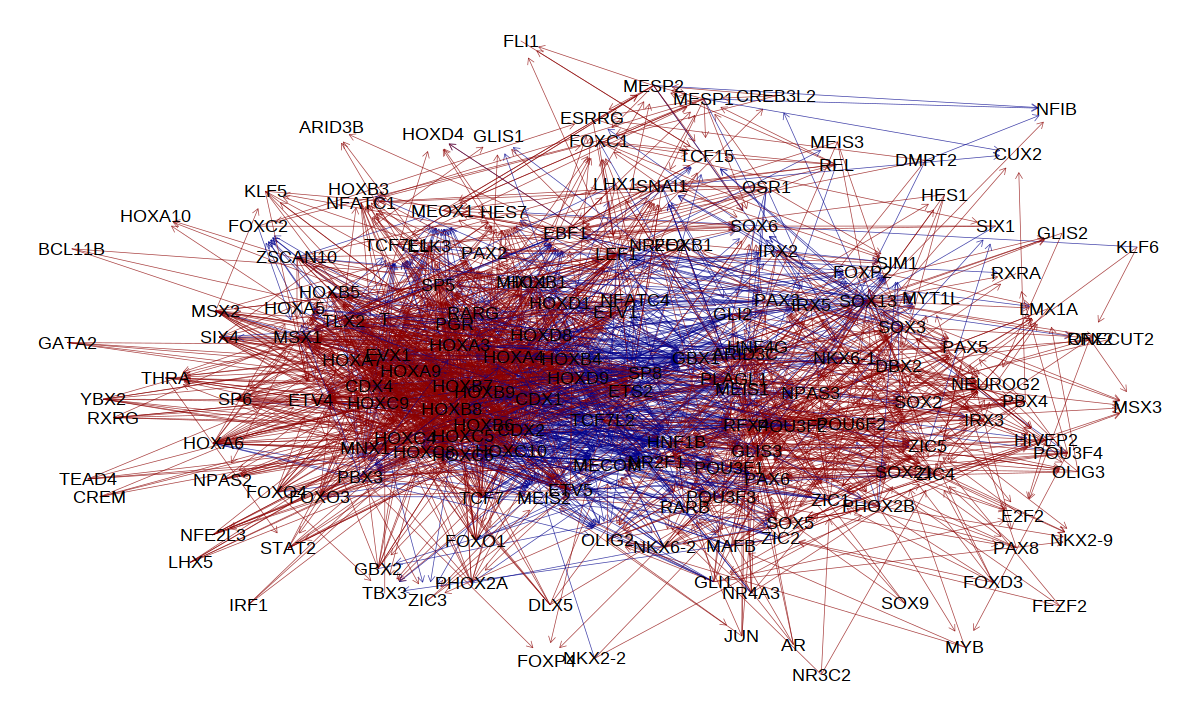

In [110]:
p <- ggraph(igraph.tbl, 'stress') +
  geom_edge_link(aes(edge_colour = sign), edge_alpha=0.75, edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
 # geom_node_point(aes(fill=celltype), size=9, stroke=0, shape=21, alpha=0.75) +
    geom_node_point(size=9, stroke=0, shape=21, alpha=0.75) +
  geom_node_text(aes(label=name), size=3.75) +
  scale_edge_colour_manual(values=c("Positive"="darkred", "Negative"="darkblue")) +
  scale_fill_manual(values=opts$celltype.colors) +
  theme_graph()
p

In [111]:
#################################################
## Plot global network, coloured by centrality ##
#################################################

set.seed(42)
p <- ggraph(igraph.tbl, 'stress') +
  geom_edge_link(edge_colour = "grey66", edge_alpha=0.50, edge_width=0.10, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  # geom_node_point(aes(fill=degree), size=8, shape=21) +
  geom_node_point(aes(fill=eigen_centrality), size=8, shape=21, alpha=0.80) +
  geom_node_text(aes(label=name), size=3.75) +
  scale_fill_gradient(low = "white", high = "orange") +
  theme_graph()

pdf(file.path(io$outdir,"global_network_eigen_centrality.pdf"), width = 4.5, height = 5)
print(p)
dev.off()

to.plot <- data.table(tf=names(V(igraph.net)), centrality = eigen_centrality(igraph.net)$vector) %>% 
  .[sample(x=.N, size=round(.N/1.5))] %>%
  setorder(-centrality) %>%
  .[,tf:=factor(tf, levels=tf)] 

# to.plot <- rbind(
#   eigen_centrality.dt %>% head(n=10),
#   eigen_centrality.dt %>% tail(n=10)
# )

p <- ggplot(to.plot, aes_string(x="centrality", y="tf")) +
  geom_point(aes(size=centrality)) +
  geom_segment(aes(yend=tf), xend=0, size=0.20) +
  scale_size_continuous(range = c(1.25,3.75)) +
  labs(y="", x="Eigenvalue centrality") +
  theme_classic() +
  guides(size="none") +
  theme(
    axis.text.x = element_text(size=rel(1.0), color="black"),
    axis.text.y = element_text(size=rel(0.75), color="black")
  )

pdf(file.path(io$outdir,"global_network_eigen_centrality_stats.pdf"), width = 4, height = 4.5)
print(p)
dev.off()

png 
  2

png 
  2

In [112]:
##################################
## Plot repressive interactions ##
##################################

set.seed(42)
p <- ggraph(igraph.tbl, 'stress') +
  geom_edge_link(aes(edge_colour = sign, edge_alpha = sign), edge_width=0.40, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  geom_node_point( aes(fill=celltype), size=8, shape=21) + #
  geom_node_text(aes(label=name), size=3) +
  scale_edge_alpha_manual(values=c("Positive"=0, "Negative"=0.80)) +
  scale_edge_colour_manual(values=c("Positive"="darkred", "Negative"="darkblue")) +
  scale_fill_manual(values=opts$celltype.colors) +
  theme_graph()

pdf(file.path(io$outdir,"global_network_repressive_interactions.pdf"), width = 5, height = 5.5)
print(p)
dev.off()

png 
  2

In [113]:
##################################
## Plot activatory interactions ##
##################################

set.seed(42)
p <- ggraph(igraph.tbl, 'stress') +
  geom_edge_link(aes(edge_colour = sign, edge_alpha = sign), edge_width=0.20, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  geom_node_point(aes(fill=celltype), size=8, shape=21) +
  geom_node_text(aes(label=name), size=3) +
  scale_edge_alpha_manual(values=c("Positive"=0.80, "Negative"=0)) +
  scale_edge_colour_manual(values=c("Positive"="darkred", "Negative"="darkblue")) +
  scale_fill_manual(values=opts$celltype.colors) +
  theme_graph()

pdf(file.path(io$outdir,"global_network_activatory_interactions.pdf"), width = 5.5, height = 5.5)
print(p)
dev.off()


png 
  2

In [114]:
######################################################################################
## Highlight a TF with pleiotropy effects (both positive and negative interactions) ##
######################################################################################

TF_of_interest <- "CDX2"

idx <- which(names(V(igraph.net))==TF_of_interest)
test <- igraph.tbl %>% activate(edges) %>% filter(from==idx)

tmp <- names(V(igraph.net))[test %>% activate(edges) %>% as_tibble() %>% .$to]
test <- test %>% activate(nodes) %>% filter(name%in%c(TF_of_interest,tmp))

set.seed(42)
p <- ggraph(test, 'stress') +
  geom_edge_link(aes(edge_colour = sign), edge_alpha=0.85, edge_width=0.65, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  geom_node_point(aes(fill=celltype), size=11, shape=21, stroke=0, alpha=0.75) +
  geom_node_text(aes(label=name), size=3.5) +
  scale_edge_colour_manual(values=c("Positive"="darkred", "Negative"="darkblue")) +
  scale_fill_manual(values=opts$celltype.colors) +
  theme_graph()

pdf(file.path(io$outdir,"CDX2_network.pdf"), width = 4, height = 4)
print(p)
dev.off()

png 
  2

In [115]:
################################
## Plot network per cell type ##
################################

celltypes.to.plot <- c("Spinal_cord","NMP","Somitic_mesoderm")

for (i in celltypes.to.plot) {
  
  # Define node color based on TF expr
  expr.values <- rna_tf_pseudobulk_scaled.mtx[,i]
  expr.values[expr.values<=0.1] <- 0.1; expr.values[expr.values>=0.9] <- 0.9
  igraph.tbl <- igraph.tbl %>% activate(nodes) %>% mutate(expr=expr.values[names(V(igraph.net))])
  
  # (TO-DO) Gray out edges of genes that are not expressed
  
  set.seed(42)
  p <- ggraph(igraph.tbl, 'stress') +
    geom_edge_link(edge_colour="gray70", edge_alpha=0.50, edge_width=0.10, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
    geom_node_point(aes(color=expr), size=8, stroke=0, alpha=0.75) +
    geom_node_text(aes(label=name), size=3.75) +
    # scale_color_gradient(low = "gray80", high = "#008B00") +
    viridis::scale_color_viridis(option="viridis") +
    theme_graph() + theme(
      legend.position = "right"
    )
  
  pdf(file.path(io$outdir,sprintf("network_coloured_by_%s_expr.pdf",i)), width = 5, height = 5.5)
  print(p)
  dev.off()
  
}

In [124]:
#######################################
## Plot network along the trajectory ##
#######################################

dir.create(file.path(io$outdir,"gif"), showWarnings = F)

ntimepoints <- 20

trajectory.dt[,pseudotime_group:=as.numeric(cut(FA1,ntimepoints))]
trajectory.dt = trajectory.dt[metacell %in% colnames(rna_tf_metacells_scaled.mtx)]
# rna_scaled.mtx <- apply(logcounts(rna_tf_filt.sce),1,minmax.normalisation) %>% t

# i <- "1"
for (i in unique(trajectory.dt$pseudotime_group)) {
  print(i)
  cells <- trajectory.dt[pseudotime_group==i,metacell]
  
  rna.expr.i <- apply(rna_tf_metacells_scaled.mtx[,cells],1,mean)
  
  #####################
  ## Plot trajectory ##
  #####################
  
  to.plot <- trajectory.dt %>% copy %>%
    .[,alpha:=1.0] %>% .[!metacell%in%cells,c("celltype","alpha"):=list("None",0.25)]
    
  p1 <- ggplot(to.plot, aes(x=FA1, y=FA2)) +
    geom_point(aes(x=FA1, y=FA2, fill=celltype), size=2.5, shape=21, alpha=1.0, data=to.plot[metacell%in%cells]) +
    geom_point(aes(x=FA1, y=FA2), size=2.5, color="grey", alpha=0.25, data=to.plot[!metacell%in%cells]) +
    # viridis::scale_fill_viridis() +
    scale_fill_manual(values=opts$celltype.colors) +
    # labs(x="Force-directed layout (Dim 1)", y="Force-directed layout (Dim 2)") +
    theme_classic() +
    ggplot_theme_NoAxes() +
    theme(
      legend.position="none"
    )
  
  ##################
  ## Plot network ##
  ##################
  
  # Define node color based on TF expr
  expr.values <- apply(rna_tf_metacells_scaled.mtx[,cells],1,mean)
  expr.values[expr.values<=0.1] <- 0.1; expr.values[expr.values>=0.9] <- 0.9
  igraph.tbl <- igraph.tbl %>% activate(nodes) %>% mutate(expr=expr.values[names(V(igraph.net))])
  
  # (TO-DO) Gray out edges of genes that are not expressed
  tmp <- tibble(tf=names(expr.values), alpha=expr.values, from=1:length(expr.values))
  igraph.tbl.i <- igraph.tbl %>% activate(edges) %>% left_join(tmp,by="from")
  
  
  set.seed(42)
  p2 <- ggraph(igraph.tbl.i, 'stress') +
    # geom_edge_link(edge_colour="gray70", edge_alpha=0.50, edge_width=0.10, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
    geom_edge_link(aes(edge_alpha=alpha, edge_width=alpha), edge_colour="gray70", arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm'), show.legend = F) +
    scale_edge_alpha_continuous(range=c(0,1)) +
    scale_edge_width_continuous(range=c(0,0.65)) +
    geom_node_point(aes(color=expr), size=14, stroke=0, alpha=0.75) +
    geom_node_text(aes(label=name), size=3.75) +
    # scale_color_gradient(low = "gray80", high = "#008B00") +
    viridis::scale_color_viridis(option="viridis") +
    # guides(edge_alpha="None") +
    theme_graph() + 
    theme(
      legend.position = "right"
    )
  
  
  # Combine plots
  p <- cowplot::plot_grid(plotlist=list(p1,p2), nrow = 1, rel_widths = c(1/3,2/3))
  outfile <- sprintf("%s/gif/%d_nmp_pseudotime_GRN.png",io$outdir,i)
  png(outfile, width = 1300, height = 650, bg = "white")
  print(p)
  dev.off()
}


# Create GIF 
library(magick)
sprintf("%s/gif/%d_nmp_pseudotime_GRN.png",io$outdir,sort(unique(trajectory.dt$pseudotime_group))) %>%
  map(image_read) %>%
  image_join %>%
  image_animate(fps=2) %>%
  image_write(quality=100, path = sprintf("%s/gif/test.gif",io$outdir))


[1] 9
[1] 14
[1] 2
[1] 10
[1] 17
[1] 1
[1] 6
[1] 18
[1] 20
[1] 4
[1] 8
[1] 16
[1] 19
[1] 3
[1] 12
[1] 15
[1] 13
[1] 5
[1] 7
[1] 11


ERROR: Error in library(magick): there is no package called ‘magick’


In [121]:
rna_tf_metacells_scaled.mtx[,cells]

ERROR: Error in rna_tf_metacells_scaled.mtx[, cells]: subscript out of bounds


In [119]:
  cells <- trajectory.dt[pseudotime_group==i,metacell]

#### Graph umap

In [54]:
as.matrix(igraph.net)

IGRAPH f774300 DNW- 170 2591 -- 
+ attr: name (v/c), weight (e/n)
+ edges from f774300 (vertex names):
 [1] CDX1   ->HES7  CDX4   ->HES7  ETS2   ->HES7  EVX1   ->HES7  HNF4G  ->HES7 
 [6] HOXA4  ->HES7  HOXB9  ->HES7  HOXD1  ->HES7  HOXD8  ->HES7  HOXD9  ->HES7 
[11] KLF5   ->HES7  KLF6   ->HES7  LEF1   ->HES7  NFATC4 ->HES7  PGR    ->HES7 
[16] POU3F1 ->HES7  SP5    ->HES7  SP6    ->HES7  TCF7   ->HES7  TLX2   ->HES7 
[21] ZSCAN10->HES7  CDX1   ->HOXB9 CDX2   ->HOXB9 CDX4   ->HOXB9 CREM   ->HOXB9
[26] ETS2   ->HOXB9 ETV1   ->HOXB9 ETV4   ->HOXB9 ETV5   ->HOXB9 EVX1   ->HOXB9
[31] FOXO1  ->HOXB9 HOXA3  ->HOXB9 HOXA4  ->HOXB9 HOXA6  ->HOXB9 HOXA7  ->HOXB9
[36] HOXA9  ->HOXB9 HOXB1  ->HOXB9 HOXB4  ->HOXB9 HOXB5  ->HOXB9 HOXB6  ->HOXB9
+ ... omitted several edges

In [61]:
test = edge_list.dt %>% dcast(from~to, value.var="weight", fill=0, drop=F) %>%
    as.data.frame(.) %>% 
    tibble::column_to_rownames('from')

In [86]:
test2 = umap(test, n_neighbors =10) %>% 
    as.data.table(., keep.rownames=T) %>%
    setnames(c('gene', 'umap1', 'umap2'))

In [91]:
test2 = merge(test2, as.data.table(rna_tf_pseudobulk_scaled.mtx,keep.rownames=T), by.x='gene', by.y='rn')

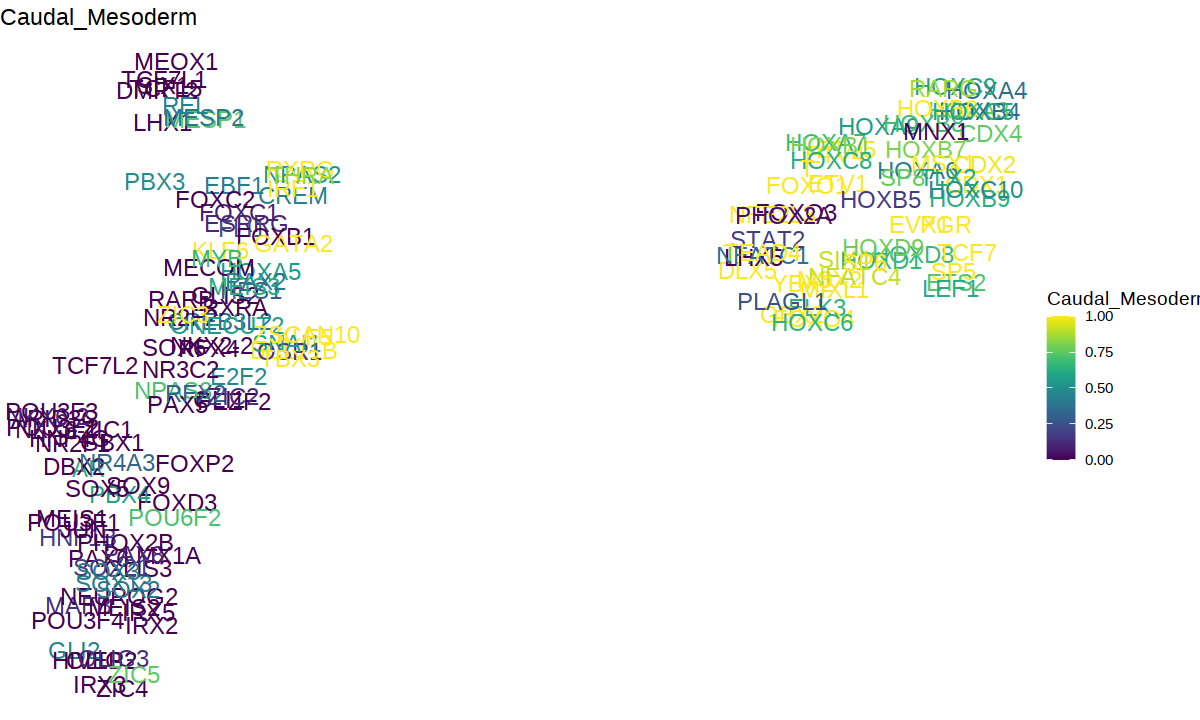

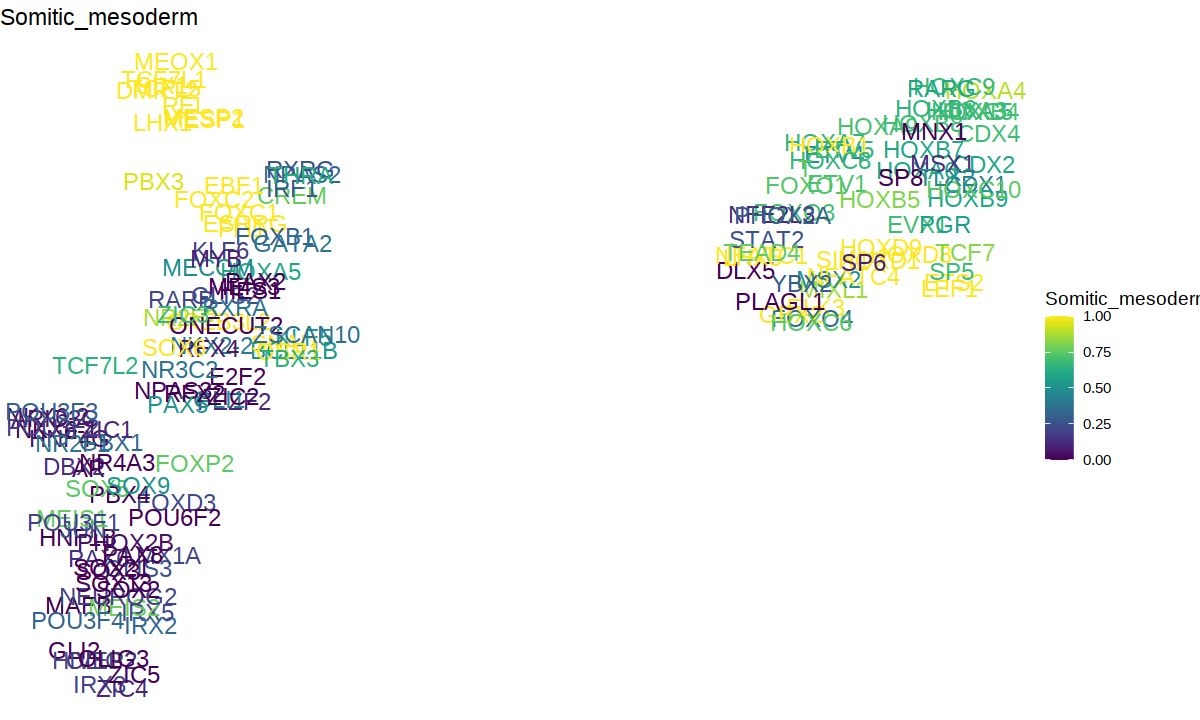

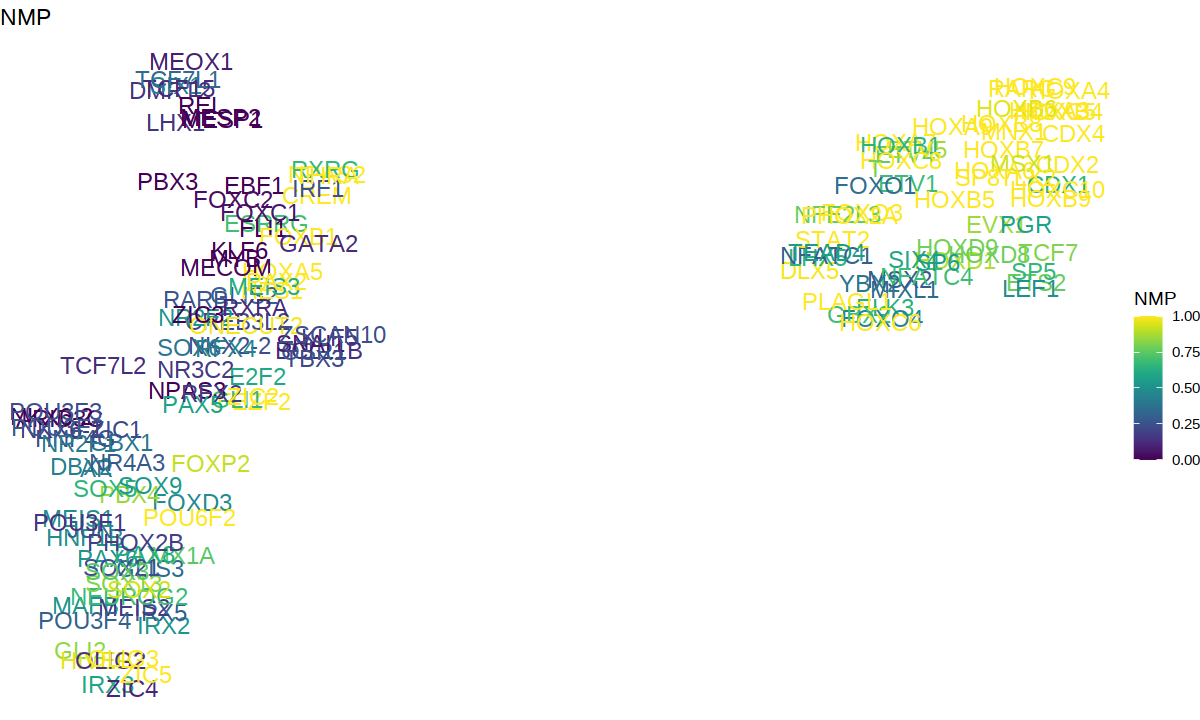

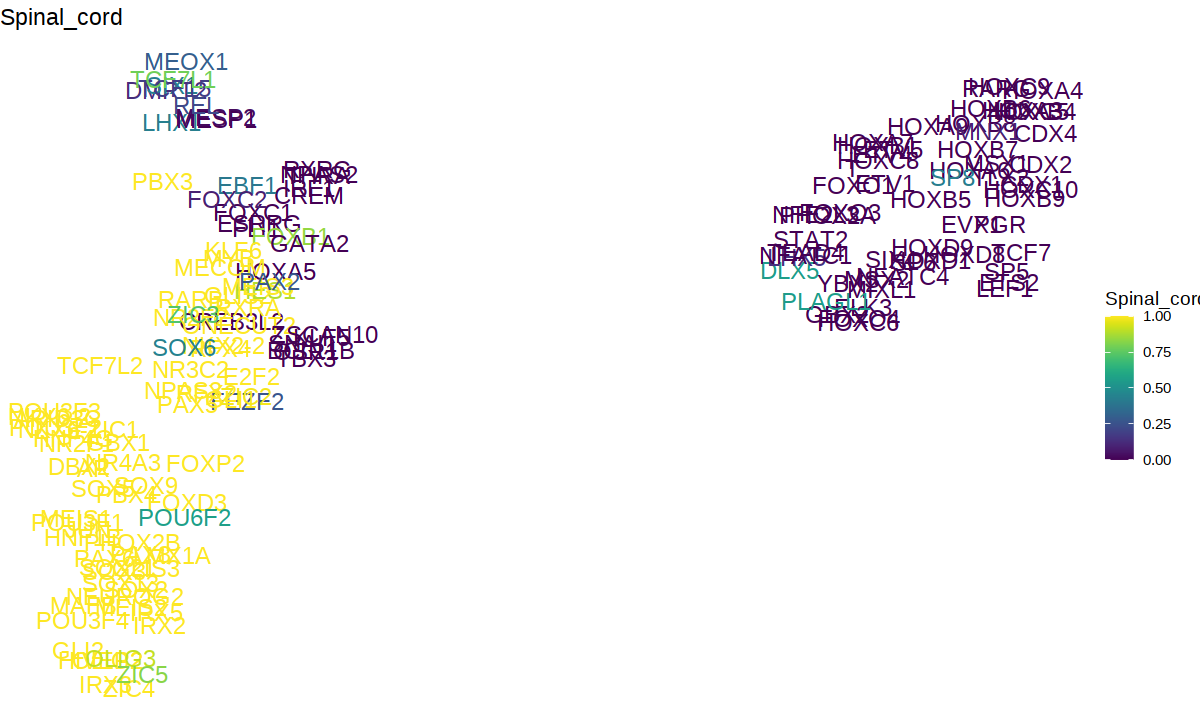

In [99]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in colnames(rna_tf_pseudobulk_scaled.mtx)){
    p = ggplot(test2, aes_string('umap1', 'umap2', label='gene', col=i)) + 
        geom_text(size=5) + 
        viridis::scale_color_viridis() + 
        ggtitle(i) + 
        theme_void()
    print(p)
}

In [101]:
marker_TFs_filt.dt <- marker_TFs_all.dt %>% 
  .[score>=opts$min_tf_score]

In [103]:
test3 = test2[gene %in% marker_TFs_filt.dt$gene]

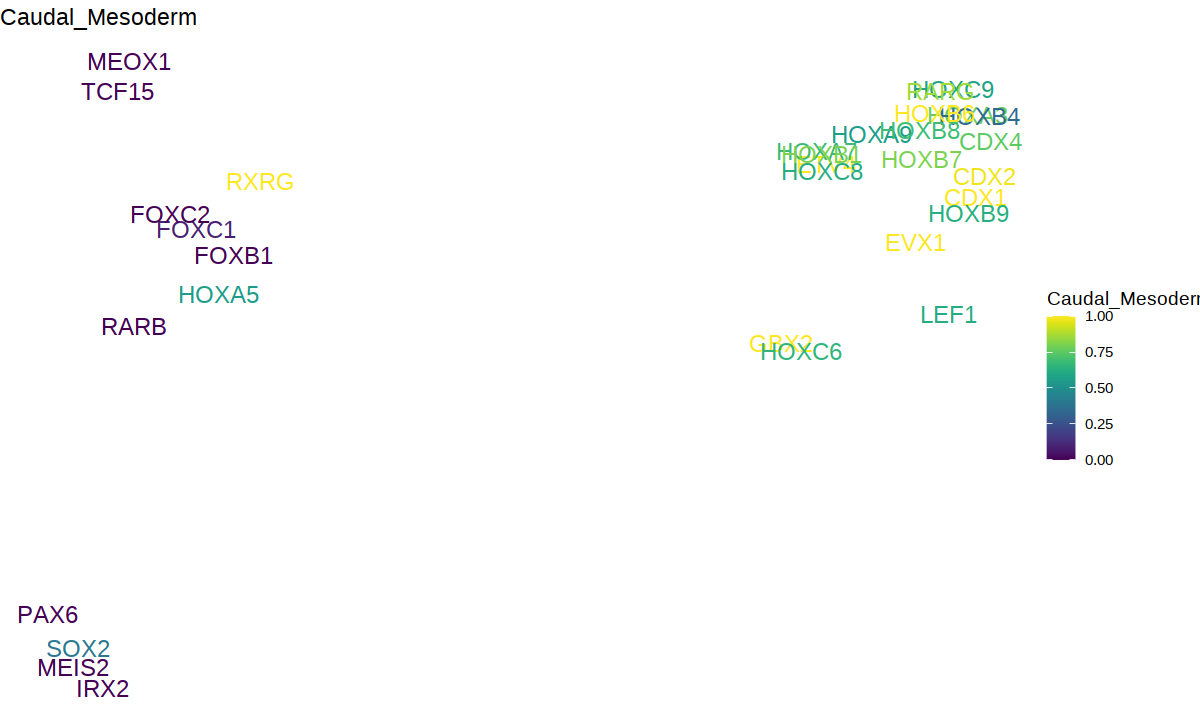

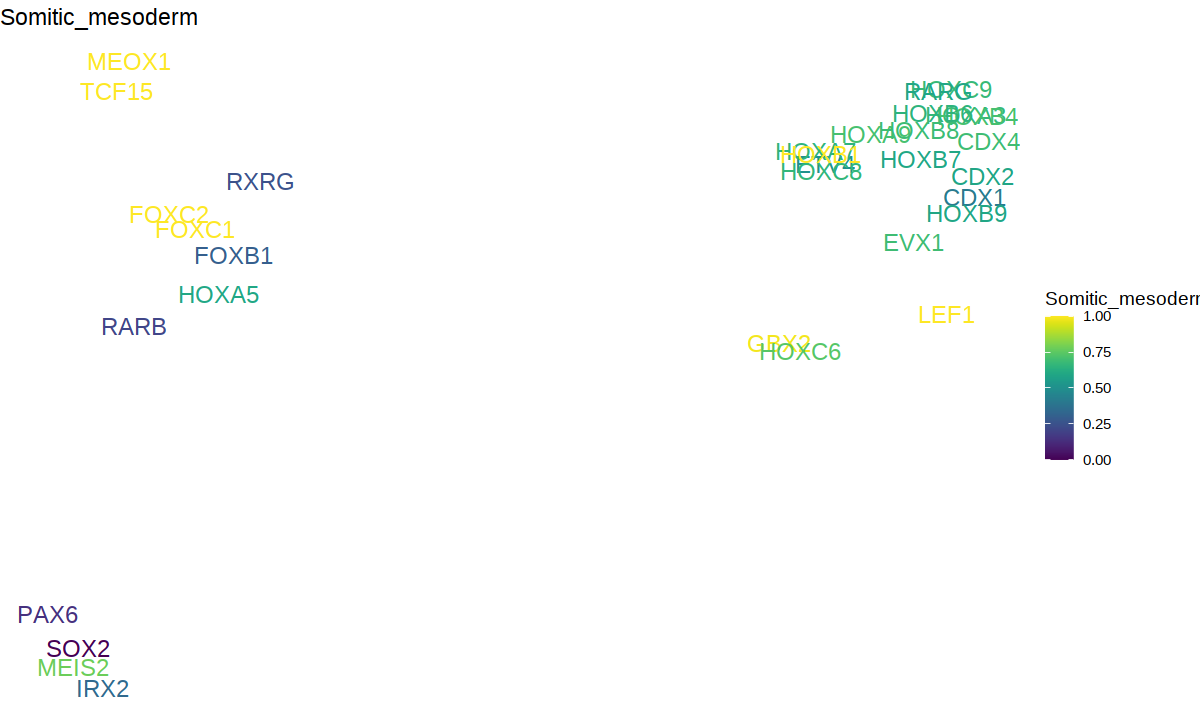

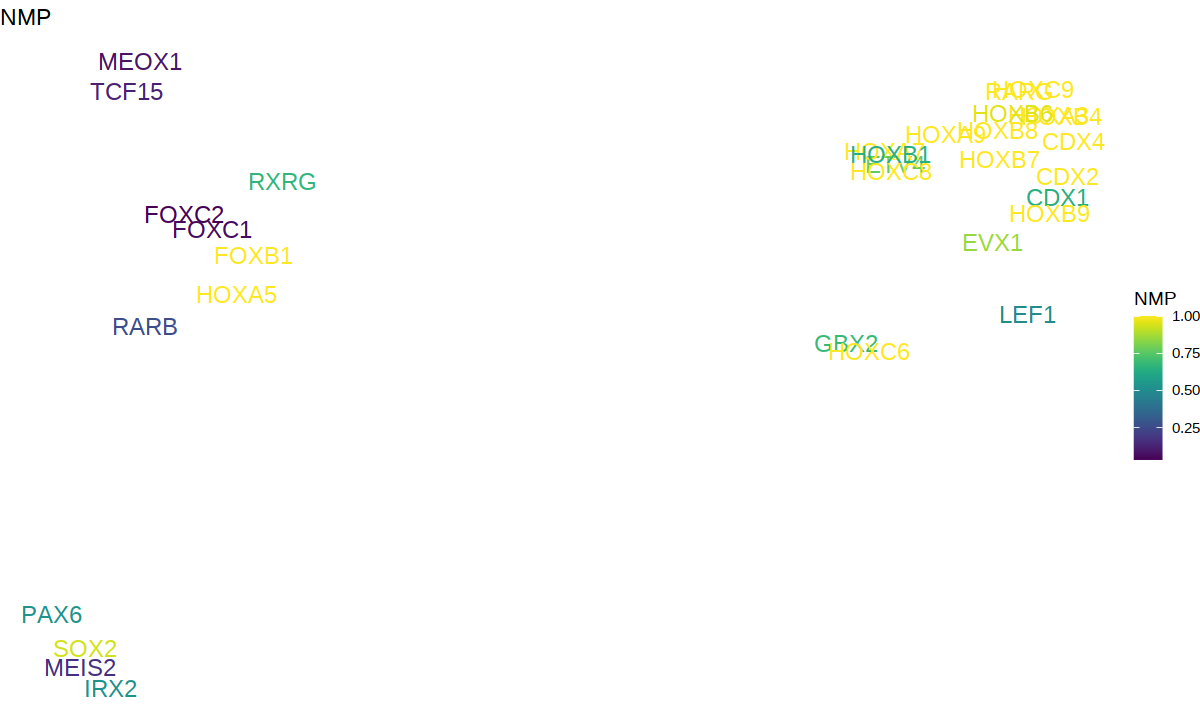

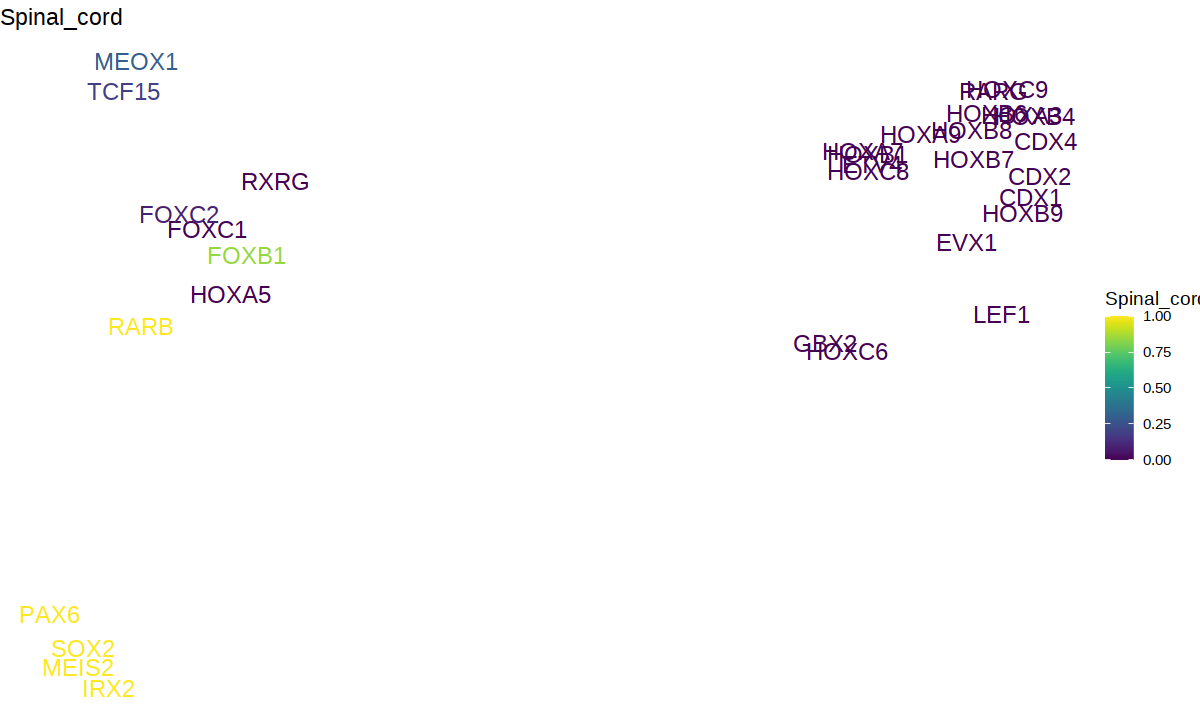

In [104]:
options(repr.plot.width=10, repr.plot.height=6)
for(i in colnames(rna_tf_pseudobulk_scaled.mtx)){
    p = ggplot(test3, aes_string('umap1', 'umap2', label='gene', col=i)) + 
        geom_text(size=5) + 
        viridis::scale_color_viridis() + 
        ggtitle(i) + 
        theme_void()
    print(p)
}